# Machine learning 

In [1]:
# %%%%%%%% imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plot_misc.machine_learning as ml
import plot_misc.example_data.examples as examples
from matplotlib.lines import Line2D

In [2]:
# constants
X_LAB = 'c-statistic change'
LAB_SIZE=14
LAB_PAD=1.2
TICKS_WD = 0.6
TLAB_SIZE = 9
TLEN = 5
VALUES='importance'
LABELS='name'
CMTOINCH = 1/2.54

# import example data
data = examples.load_lollipop_data()
data = data[data[VALUES] > 0]
data.head()

,name,importance
0,Height (cm),0.046065
1,Female sex,0.043915
2,R-axis (degrees),0.036310
3,History of LTVA,0.027412
4,ECG Embeding 26,0.020835


## Lollipop plots


Lollipop plots are a clean alternative to bar plots, especially for visualising ranked values such as feature importance or effect sizes. 
Each line connects a baseline (usually zero) to a value, ending in a dot. 
They are particularly useful when space is limited or to emphasise ordering.

(0.0, 0.048247475455820456)

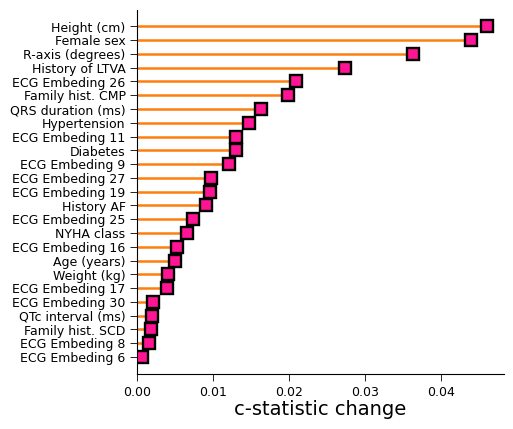

In [3]:
fig, ax = plt.subplots(1, figsize=(12*CMTOINCH, 12*CMTOINCH))

# make plot
_, ax = ml.lollipop(
     values=data[VALUES].to_numpy(), labels=data[LABELS].to_numpy(),
    line_color='tab:orange', linewidth=1.8, dot_color='deeppink', 
    dot_edge_color='black', dot_size=8, dot_edge_size=1.7, reverse_feature_order=True, 
    ax=ax, kwargs_plot_dict={'marker':'s'},
                    )
# labels and ticks
ax.tick_params(axis="x", labelsize=TLAB_SIZE, length=TLEN, width=TICKS_WD,
        rotation=0)
ax.tick_params(axis="y", labelsize=TLAB_SIZE, length=TLEN, width=TICKS_WD,
        rotation=0)
# add lables
ax.set_ylabel('')
ax.set_xlabel(X_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)
# limits
xlim = ax.get_xlim()
ax.set_xlim(0, xlim[1]*0.95)

(0.0, 0.048247475455820456)

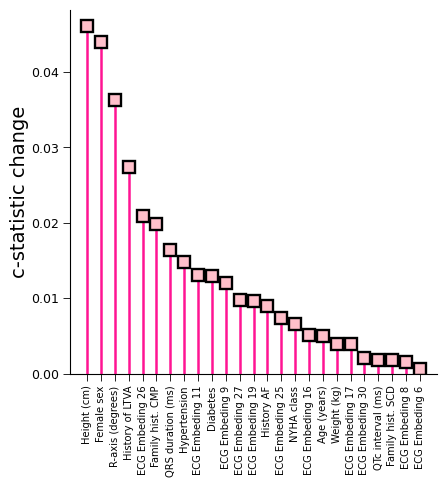

In [4]:
# A vertical version
fig, ax = plt.subplots(1, figsize=(12*CMTOINCH, 12*CMTOINCH))

# make plot
_, ax = ml.lollipop(
     values=data[VALUES].to_numpy(), labels=data[LABELS].to_numpy(),
    line_color='deeppink', linewidth=1.8, dot_color='pink', 
    dot_edge_color='black', dot_size=8, dot_edge_size=1.7, reverse_feature_order=False, 
    vertical=True,
    ax=ax, kwargs_plot_dict={'marker':'s'},
                    )
# labels and ticks
ax.tick_params(axis="x", labelsize=TLAB_SIZE*.8, length=TLEN, width=TICKS_WD,
        rotation=90)
ax.tick_params(axis="y", labelsize=TLAB_SIZE, length=TLEN, width=TICKS_WD,
        rotation=0)
# add lables
ax.set_xlabel('')
ax.set_ylabel(X_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)
# limits
ylim = ax.get_ylim()
ax.set_ylim(0, ylim[1]*0.95)

## Calibration plots

In [5]:
# load data 
data = examples.load_calibration_bins()

# constants
X_LAB = 'Predicted risk'
Y_LAB = 'Observed risk'
LINE_COL = ['lightcoral', 'lightgreen']
LINE_LW = [1.5, 1.5]
LINE_LS = ['--', '--']
DOT_COL = ['lightcoral', 'lightgreen']
DOT_MARK = ['o', 'o']


data.head()

,average_predict_risk,average_observed_risk,lower_observed_risk,upper_observed_risk,no_subjects
bins,,,,,
0,0.077704,0.071429,0.008770,0.235035,28
1,0.158541,0.178571,0.060643,0.368933,28
2,0.238182,0.285714,0.132237,0.486668,28
3,0.340155,0.259259,0.111145,0.462849,27
4,0.468930,0.464286,0.275109,0.661301,28


Text(0.5, 0, 'Predicted risk')

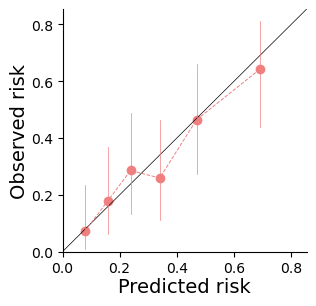

In [6]:
# make figure
fig, ax = plt.subplots(1, figsize=(8*CMTOINCH, 8*CMTOINCH))

# make plot
_, ax = ml.calibration(data, predicted='average_predict_risk', observed='average_observed_risk',
                       lower_observed='lower_observed_risk', upper_observed='upper_observed_risk',
                      ax=ax)
# labels
ax.set_ylabel(Y_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)
ax.set_xlabel(X_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)

Text(0.5, 0, 'Predicted risk')

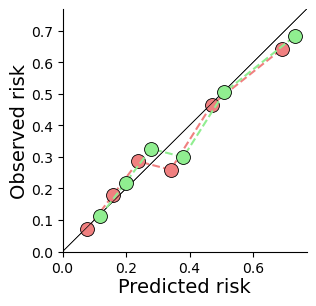

In [7]:
# multiple lines
data2 = data.copy()
data2[['average_predict_risk', 'average_observed_risk']] = \
     data2[['average_predict_risk', 'average_observed_risk']] + 0.04
# making dict
data_dict = {'one': data, 'two': data2}

# make figure
fig, ax = plt.subplots(1, figsize=(8*CMTOINCH, 8*CMTOINCH))

# make plot
_, ax = ml.calibration(data_dict, predicted='average_predict_risk', observed='average_observed_risk',
                       ci_colour=None, ci_linewidth=None, 
                       dot_marker=DOT_MARK, dot_colour=DOT_COL, 
                       line_colour=LINE_COL, line_linestyle=LINE_LS, line_linewidth=LINE_LW,
                       kwargs_dot_dict={'s':100, 'edgecolor':'black', 'linewidths':0.6, 'zorder':2},
                       ax=ax)
# labels
ax.set_ylabel(Y_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)
ax.set_xlabel(X_LAB, fontsize=LAB_SIZE, labelpad=LAB_PAD)

## Decision curve plots
Decision cruve analysis compares the net-benefit (representing the pendalised difference between true and false positives) of any number of models across a decision threshold (the predicted probabilities). Typically these plots include extereme models were either everyone is treated or not. 

(<Figure size 300x300 with 1 Axes>,
 <Axes: xlabel='Threshold', ylabel='Net benefit'>)

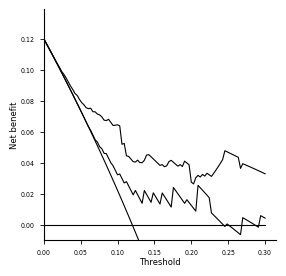

In [8]:
# import example data
data = examples.load_net_benefit_data()
# calculate the net benefit
nb_obj = ml.DecisionCurve(data)
nb_obj.calc_net_benefit(
    outcome='Composite outcome',modelnames=['DCM-PROGRESS', 'maggic (3-years risk of death)'],
    thresholds=list(np.linspace(0.0, 0.3, 100))
)
# plotting
nb_obj.plot(figsize=(3,3))

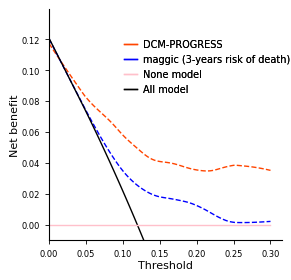

In [9]:
# Let's add some more colour and linetypes, and smoothing
MODEL_NAMES = nb_obj.MODEL_NAMES
COL_DICT = {k:j for j, k in zip(['orangered', 'blue', 'pink', 'black'], MODEL_NAMES)}
LINE_DICT = {k:j for j, k in zip(['--', '--', '-', '-'], MODEL_NAMES)}
nb_obj.LABEL_FONT_SIZE=8
nb_obj.TICK_LAB_SIZE=6
# plotting
f, ax = nb_obj.plot(figsize=(3,3), col_dict=COL_DICT, line_dict=LINE_DICT, 
           linewidth=1, lowess_frac=1/3, kwargs_lowess={'it':3})
# adding a legend
cmap = COL_DICT
patches = [Line2D([0], [0], color=v, label=k, lw=1) for k, v in cmap.items()]
leg1 = ax.legend(handles=patches , ncol=1,                
                    loc = 'center',
                    bbox_to_anchor=(0.68, 0.75),
                    borderpad=0.0, handlelength=1.3,columnspacing=0.0,
                    handletextpad=0.6, frameon=False, fancybox=False, shadow=False,
                    fontsize=7, markerscale=0.05,
                    )
ax.add_artist(leg1)

In [10]:
help(ml)

Help on module plot_misc.machine_learning in plot_misc:

NAME
    plot_misc.machine_learning

DESCRIPTION
    Figure templates for visualising performance and interpretability of
    machine learning models.
    
    This module provides reusable plotting utilities for common visualisations in
    machine learning workflows, including lollipop charts for feature importance,
    calibration plots for model reliability assessment, and decision curve
    analysis (DCA) plots for evaluating clinical utility.
    
    Functions
    ---------
    lollipop(values, labels, ...)
        Draws a line-and-dot chart as a visual alternative to bar plots.
    
    calibration(data, observed, predicted, ...)
        Creates calibration plots comparing observed and predicted risks with
        optional confidence intervals.
    
    Classes
    -------
    DecisionCurve
        A class to compute and plot decision curves, quantifying net benefit
        across varying risk thresholds.

CLASSES
    bui